import pandas as pd
import numpy as np


In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("hospital.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
df.isnull().sum()
df["Medical Condition"].values
df["Medical Condition"]=df["Medical Condition"].str.lower()
df["Medical Condition"]

0              cancer
1             obesity
2             obesity
3            diabetes
4              cancer
             ...     
55495          asthma
55496         obesity
55497    hypertension
55498       arthritis
55499       arthritis
Name: Medical Condition, Length: 55500, dtype: str

In [8]:
import matplotlib.pyplot as plt


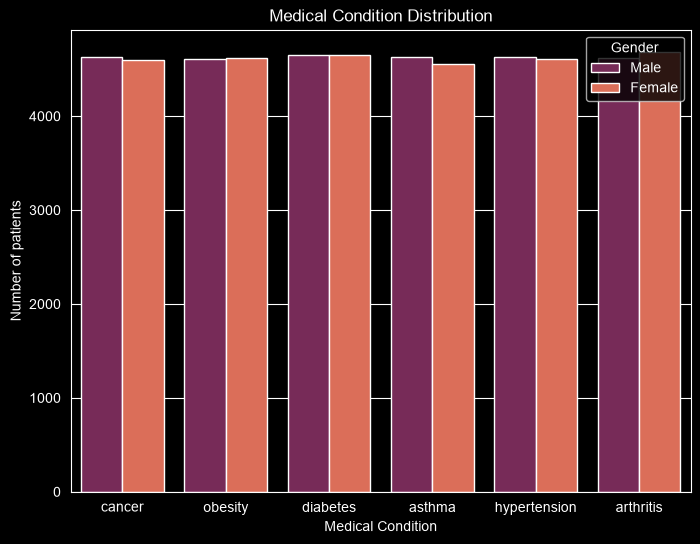

In [13]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="Medical Condition",
    hue="Gender",
    palette="rocket",




)
plt.title("Medical Condition Distribution")
plt.xlabel("Medical Condition")
plt.ylabel("Number of patients")
plt.show()

Text(0, 0.5, 'Number of patients')

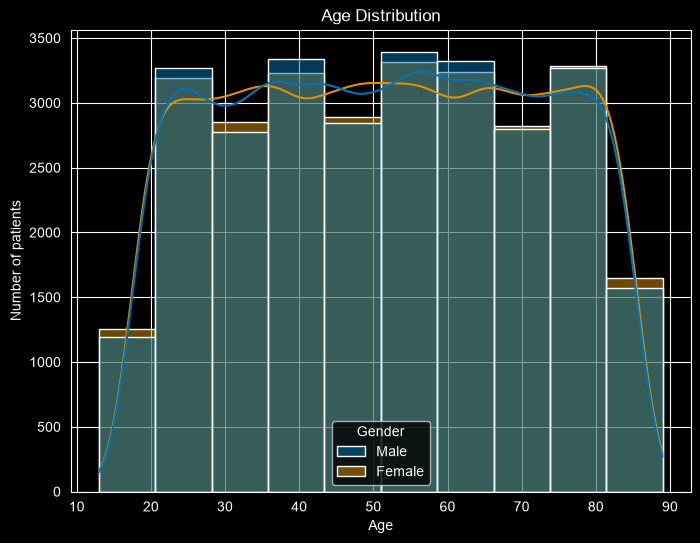

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=df,
    x="Age"
    ,hue="Gender",
    palette="colorblind",

    kde=True,
    bins=10

)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of patients")

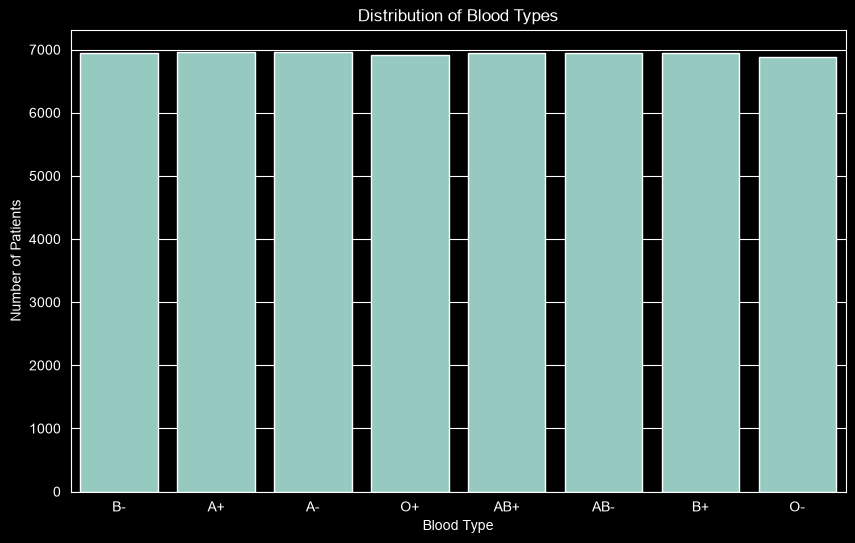

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Blood Type"
)

plt.title("Distribution of Blood Types")
plt.xlabel("Blood Type")
plt.ylabel("Number of Patients")

plt.show()

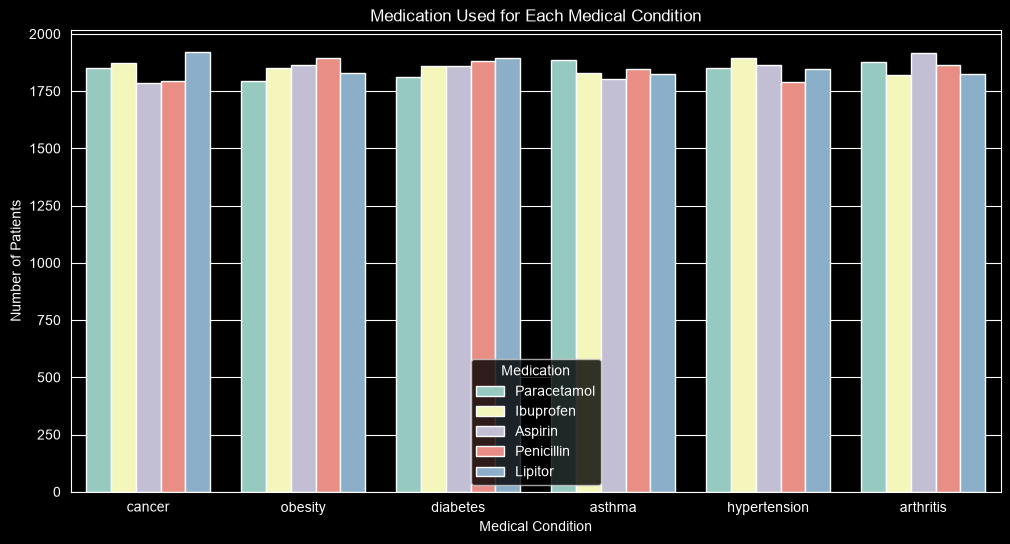

In [20]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Medical Condition",
    hue="Medication"
)

plt.title("Medication Used for Each Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")

plt.legend(title="Medication")
plt.show()

Medical Dataset — Machine Learning Project

We’ll treat Billing Amount as the target variable and build a regression project to predict a patient's hospital billing amount from the available information.

One important point before we start: the data you pasted contains only 11 records. That is enough for learning the workflow, but far too small for a reliable real-world ML model. If your original CSV contains thousands of rows, use the complete CSV for the actual project.

# Logistic Regression — Healthcare Dataset

In this project, we will build a multiclass Logistic Regression model
to predict a patient's Medical Condition.

The workflow will include:

1. Data preparation
2. Feature selection
3. Train-test split
4. Categorical encoding
5. Feature scaling
6. Logistic Regression
7. Predictions
8. Model evaluation
9. Confusion matrix
10. Classification report

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [22]:
df = pd.read_csv("hospital.csv")

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 5. Select Features

We should not blindly give every column to the model.

`Name` is an identifier and does not provide useful medical information.

`Doctor` and `Hospital` can also have extremely high numbers of
unique categories and may cause unnecessary complexity.

The raw admission and discharge dates will also be removed for now.
We can later perform feature engineering on them.

In [30]:
X = df.drop(
    columns=[
        "Medical Condition",
        "Name",
        "Doctor",
        "Hospital",
        "Insurance Provider",
        "Billing Amount",
        "Room Number",
        "Date of Admission",
        "Discharge Date"
    ]
)

y = df["Medical Condition"]

## 6. Separate Features and Target

`X` contains the input features.

`y` contains the target that the Logistic Regression model will
try to predict.

In [31]:
print("X shape:", X.shape)
print("y shape:", Y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(Y.unique())

X shape: (55500, 6)
y shape: (55500,)

Features:
['Age', 'Gender', 'Blood Type', 'Admission Type', 'Medication', 'Test Results']

Target classes:
<ArrowStringArray>
['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
Length: 6, dtype: str


In [32]:
numerical_features=[

    "Age"
]
categorical_features = [
    "Gender",
    "Blood Type",
    "Admission Type",
    "Medication",
    "Test Results"
]

In [33]:
X.head()


,Age,Gender,Blood Type,Admission Type,Medication,Test Results
0,30,Male,B-,Urgent,Paracetamol,Normal
1,62,Male,A+,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Emergency,Aspirin,Normal
3,28,Female,O+,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Urgent,Penicillin,Abnormal


In [34]:
Y.head()

0      Cancer
1     Obesity
2     Obesity
3    Diabetes
4      Cancer
Name: Medical Condition, dtype: str

Target Class Distribution

We need to check how many observations belong to each medical
condition.

This is important because an imbalanced target can make accuracy
misleading.

In [35]:
Y.value_counts()


Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

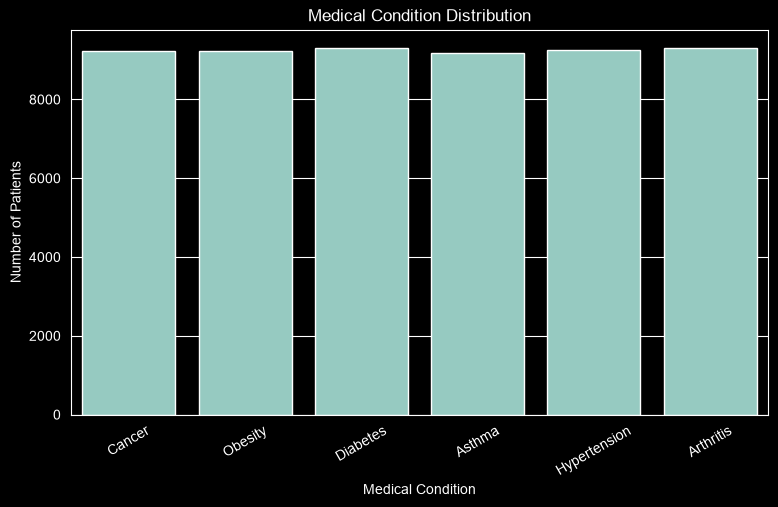

In [36]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Medical Condition"
)

plt.title("Medical Condition Distribution")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")

plt.xticks(rotation=30)
plt.show()

## 11. Train-Test Split

We divide our dataset into training and testing sets.

The training set is used to learn the patterns.

The testing set is used to evaluate how well the model performs
on previously unseen data.

We use 80% for training and 20% for testing.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (44400, 6)
X_test : (11100, 6)
y_train: (44400,)
y_test : (11100,)


## 14. Preprocessing

Machine learning algorithms work with numerical values.

We therefore need to transform our data.

For the numerical feature `Age`, we use `StandardScaler`.

For categorical features, we use `OneHotEncoder`.

`handle_unknown="ignore"` prevents errors if the test set contains
a category that was not present in the training set.

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 15. Build the Logistic Regression Pipeline

A pipeline combines preprocessing and model training into one
workflow.

The pipeline will:

1. Scale `Age`
2. One-hot encode categorical features
3. Train Logistic Regression

This also helps prevent data leakage because preprocessing is
learned only from the training data.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

## 16. Train Logistic Regression

We now train the complete pipeline using the training data.

The model learns the relationship between the patient's features
and their medical condition.

In [51]:
model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 17. Make Predictions

We now use the trained model to predict the medical conditions
of patients in the test set.

The test data has not been used to train the model.

In [52]:
Predictions = model.predict(X_test)

print(Predictions)

['Asthma' 'Hypertension' 'Hypertension' 'Arthritis' 'Diabetes' 'Obesity'
 'Asthma' 'Arthritis' 'Hypertension' 'Obesity' 'Obesity' 'Hypertension'
 'Obesity' 'Cancer' 'Hypertension' 'Hypertension' 'Cancer' 'Diabetes'
 'Obesity' 'Cancer' 'Obesity' 'Cancer' 'Hypertension' 'Arthritis'
 'Arthritis' 'Cancer' 'Cancer' 'Diabetes' 'Asthma' 'Diabetes' 'Asthma'
 'Cancer' 'Arthritis' 'Hypertension' 'Obesity' 'Diabetes' 'Cancer'
 'Arthritis' 'Arthritis' 'Obesity' 'Cancer' 'Cancer' 'Diabetes' 'Cancer'
 'Diabetes' 'Diabetes' 'Hypertension' 'Cancer' 'Asthma' 'Asthma' 'Cancer'
 'Arthritis' 'Arthritis' 'Arthritis' 'Arthritis' 'Obesity' 'Arthritis'
 'Arthritis' 'Hypertension' 'Hypertension' 'Asthma' 'Arthritis' 'Asthma'
 'Diabetes' 'Hypertension' 'Asthma' 'Arthritis' 'Diabetes' 'Asthma'
 'Hypertension' 'Hypertension' 'Hypertension' 'Arthritis' 'Cancer'
 'Arthritis' 'Cancer' 'Arthritis' 'Hypertension' 'Diabetes' 'Arthritis'
 'Cancer' 'Diabetes' 'Arthritis' 'Cancer' 'Arthritis' 'Asthma' 'Arthritis'
 'Hypert

In [54]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": Predictions
})

comparison

,Actual,Predicted
0,Cancer,Asthma
1,Obesity,Hypertension
2,Arthritis,Hypertension
3,Hypertension,Arthritis
4,Asthma,Diabetes
...,...,...
11095,Obesity,Diabetes
11096,Hypertension,Asthma
11097,Hypertension,Hypertension
11098,Diabetes,Obesity


In [55]:
comparison["Correct"] = (
    comparison["Actual"] == comparison["Predicted"]
)

comparison

,Actual,Predicted,Correct
0,Cancer,Asthma,False
1,Obesity,Hypertension,False
2,Arthritis,Hypertension,False
3,Hypertension,Arthritis,False
4,Asthma,Diabetes,False
...,...,...,...
11095,Obesity,Diabetes,False
11096,Hypertension,Asthma,False
11097,Hypertension,Hypertension,True
11098,Diabetes,Obesity,False


In [56]:
correct = comparison["Correct"].sum()
incorrect = (~comparison["Correct"]).sum()

print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)

Correct Predictions: 1865
Incorrect Predictions: 9235


In [57]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, Predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.1680
Accuracy: 16.80%


In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        Predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Arthritis       0.17      0.19      0.18      1862
      Asthma       0.17      0.10      0.12      1837
      Cancer       0.16      0.20      0.18      1845
    Diabetes       0.17      0.16      0.16      1861
Hypertension       0.18      0.23      0.20      1849
     Obesity       0.16      0.14      0.15      1846

    accuracy                           0.17     11100
   macro avg       0.17      0.17      0.17     11100
weighted avg       0.17      0.17      0.17     11100



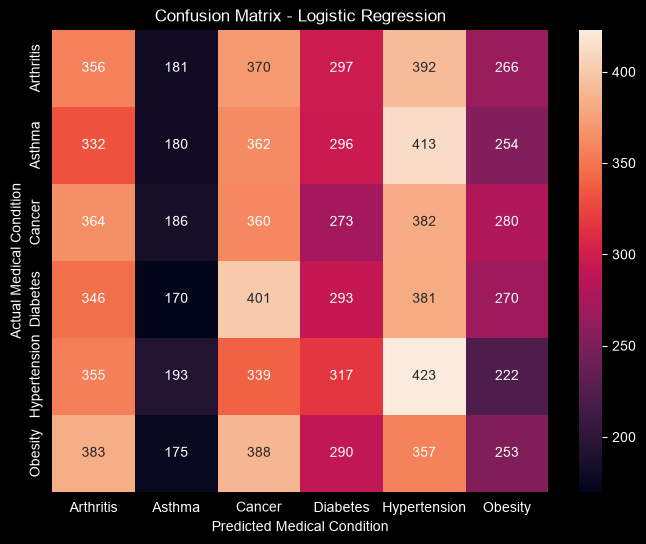

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    Predictions,
    labels=model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Medical Condition")
plt.ylabel("Actual Medical Condition")

plt.show()

In [60]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Training Accuracy: 0.1768
Testing Accuracy:  0.1680
